In [ ]:
# --- arranque en Colab (no hace nada fuera de Colab) -----------------------
# Colab arranca en /content con un entorno vacío: sin esta celda el
# `import environment` siguiente falla con ModuleNotFoundError.
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/facurie/Proyecto1_IA_Generativa.git"
    REPO_DIR = "Proyecto1_IA_Generativa"

    repo_path = os.path.join("/content", REPO_DIR)
    if not os.path.isdir(repo_path):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, repo_path], check=True)
    os.chdir(repo_path)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True
    )

    # El disco de Colab es EFÍMERO: cada checkpoint se pierde cuando el entorno de ejecución
    # se desconecta (~90 min de inactividad en el plan gratuito), y las Etapas 3, 4 y 5 necesitan
    # todas los checkpoints de la Etapa 2. Descomentá para guardarlos en Drive en su lugar.
    #
    # Notar `islink`, no `exists`: importar `environment` crea un directorio checkpoints/
    # REAL, y `exists` entonces saltearía el enlace en silencio y mandaría cada
    # checkpoint de vuelta al disco efímero.
    #
    # from google.colab import drive
    # drive.mount("/content/drive")
    # PERSISTENT = "/content/drive/MyDrive/Proyecto1_IA_Generativa/checkpoints"
    # os.makedirs(PERSISTENT, exist_ok=True)
    # if os.path.islink("checkpoints"):
    #     print("checkpoints ->", os.readlink("checkpoints"))
    # elif os.path.isdir("checkpoints"):
    #     print("ADVERTENCIA: checkpoints/ ya es un directorio real, así que NO está en Drive.")
    #     print("Mové su contenido a", PERSISTENT, ", borralo, y volvé a ejecutar esta celda.")
    # else:
    #     os.symlink(PERSISTENT, "checkpoints")
    #     print("checkpoints ->", PERSISTENT)

    print("Arranque en Colab OK. Directorio de trabajo:", os.getcwd())

# Etapa 1 · Tokenización — un BPE propio

**Grupo:** Facundo Guledjian · Galo Resnik · Lucas Allara · Facundo Riedel

Un tokenizador no es un default que se hereda: se entrena sobre *estos* datos, y el tamaño del
vocabulario (`V`) se paga contra el largo de las secuencias (`T`). Este notebook:

1. entrena un BPE a nivel byte sobre un subconjunto de TinyStories;
2. verifica que codificar → decodificar devuelva exactamente el texto original;
3. muestra los primeros merges que aprendió;
4. lo compara contra el tokenizador de GPT-2 (`tiktoken`, encoding `gpt2`) sobre cuentos que no vio;
5. barre el tamaño del vocabulario para ver el toma y daca `V ↔ T` con números;
6. mide cuánto de un cuento entra en cada `block_size` candidato — insumo directo de la Etapa 2.

**Produce:** `checkpoints/tokenizer.json`, que leen las Etapas 2 a 5.

### Qué encontramos, en corto

- **El tokenizador es un resumen del corpus.** Sus primeros merges arman *the*, *and*, *to*, *he*, *was* y el sufijo
  *-ed*: el esqueleto de un cuento contado en pasado.
- **Con un vocabulario 6 veces más chico que el de GPT-2, partimos los mismos cuentos en un 1,7% menos de tokens.** En
  un corpus de vocabulario angosto, con 8.192 tokens casi cada palabra ya es un token, y agrandar `V` no compra casi
  nada.
- **El vocabulario se paga en parámetros:** la tabla de embeddings y la capa de salida suman 4,19M, cerca del 72% del
  modelo ancho de la Etapa 2.
- **Achicarlo tampoco es gratis:** con `V = 512` los cuentos quedan un 78% más largos, y un tercio de ese vocabulario
  son bytes que no aparecen nunca.
- **Con `block_size = 256` entra entero el 90% de los cuentos**, aunque que un cuento "entre" no quiere decir que el
  modelo lo vea entero.

Debajo de cada resultado agregamos una **lectura**. Al final están las respuestas a las preguntas, las decisiones, las
dudas que nos quedan y un anexo con cómo medimos los números que no imprimen las celdas.

In [2]:
import environment  # noqa: F401  (primero siempre: caché de HF, stdout UTF-8, checkpoints/)

environment.summary()

# Entrenar un BPE es barato incluso en CPU (un par de minutos), así que acá la corrida completa es el default.
SMOKE_TEST = False
SEED = 1337

VOCAB_SIZE = 8_192
EOT = "<|endoftext|>"  # separa cuentos; el único token especial
N_TRAIN_STORIES = 10_000 if SMOKE_TEST else 100_000  # split train: de acá salen los merges
N_EVAL_STORIES = 500 if SMOKE_TEST else 5_000  # split validation: el tokenizador nunca lo ve
TOKENIZER_PATH = environment.CHECKPOINTS / "tokenizer.json"

ENTORNO
os             : Linux 6.18.48-gentoo-lean
python         : 3.14.7
venv           : /home/lucas/Proyecto1_IA_Generativa/.venv
cpu            : AMD Ryzen 9 8945HX with Radeon Graphics
logical_cores  : 32
torch          : 2.14.0+cu130
torch_threads  : 16
cuda_available : True
gpu            : NVIDIA GeForce RTX 5070 Laptop GPU
gpu_memory_gb  : 8.08
ram_total_gb   : 32.9
ram_free_gb    : 27.4
--------------------------------------------------------------
HF_HOME        : /home/lucas/Proyecto1_IA_Generativa/.hf_cache
ca_bundle      : no presente (normal)


In [3]:
from data import load_tinystories

train_texts = list(load_tinystories("train", limit=N_TRAIN_STORIES)["text"])
eval_texts = list(load_tinystories("validation", limit=N_EVAL_STORIES)["text"])

print(f"cuentos para entrenar el BPE : {len(train_texts):>7,}  (split train)")
print(f"cuentos para medir           : {len(eval_texts):>7,}  (split validation, held-out)")

cuentos para entrenar el BPE : 100,000  (split train)
cuentos para medir           :   5,000  (split validation, held-out)


## Entrenar el BPE

A nivel byte, como GPT-2: el alfabeto inicial son los 256 bytes, así que cualquier string se puede
codificar y no hace falta un token `<unk>`. El pre-tokenizador `ByteLevel` corta en palabras y codifica el
espacio que las precede como `Ġ` (U+0120): el token de `" dog"` es el string `"Ġdog"`.

In [4]:
import time

from tokenizers import Tokenizer, decoders, models, pre_tokenizers, trainers


def train_bpe(texts: list[str], vocab_size: int) -> Tokenizer:
    """BPE a nivel byte entrenado sobre `texts`, con `<|endoftext|>` como único token especial."""
    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=[EOT],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
        show_progress=False,
    )
    batches = (texts[i : i + 1_000] for i in range(0, len(texts), 1_000))
    tokenizer.train_from_iterator(batches, trainer=trainer, length=len(texts))
    return tokenizer


t0 = time.perf_counter()
tokenizer = train_bpe(train_texts, VOCAB_SIZE)
print(f"vocabulario: {tokenizer.get_vocab_size():,} tokens · entrenado en {time.perf_counter() - t0:.1f}s")

vocabulario: 8,192 tokens · entrenado en 10.3s


## Ida y vuelta

`decode(encode(s)) == s` tiene que valer para *todos* los cuentos held-out, no para un par elegidos a mano.
Si falla uno solo, hay un bug de configuración (típicamente, el decoder no coincide con el pre-tokenizador).

In [5]:
failures = [s for s in eval_texts if tokenizer.decode(tokenizer.encode(s).ids) != s]
print(f"ida y vuelta exacta: {len(eval_texts) - len(failures):,}/{len(eval_texts):,} cuentos")
assert not failures, f"primer cuento que no vuelve igual: {failures[0][:200]!r}"

example = eval_texts[0]
encoding = tokenizer.encode(example)
print()
print(example[:300], "...")
print()
print(f"{len(encoding.ids)} tokens; los primeros 40:")
print(encoding.tokens[:40])

ida y vuelta exacta: 5,000/5,000 cuentos

Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."

After playing with the car, Kitty and Spot felt thirsty. They found a small pond with clear water. They drank the water and felt very happy. They ...

82 tokens; los primeros 40:
['Spot', '.', 'ĠSpot', 'Ġsaw', 'Ġthe', 'Ġshiny', 'Ġcar', 'Ġand', 'Ġsaid', ',', 'Ġ"', 'Wow', ',', 'ĠKitty', ',', 'Ġyour', 'Ġcar', 'Ġis', 'Ġso', 'Ġbright', 'Ġand', 'Ġclean', '!"', 'ĠKitty', 'Ġsmiled', 'Ġand', 'Ġreplied', ',', 'Ġ"', 'Thank', 'Ġyou', ',', 'ĠSpot', '.', 'ĠI', 'Ġpolish', 'Ġit', 'Ġevery', 'Ġday', '."']


### Lectura: qué le pasa a un cuento real

- **Ida y vuelta: 5.000 de 5.000.** Como el alfabeto de partida son los 256 bytes, cualquier texto se puede escribir con
  estos tokens y no se pierde nada. Ojo: que no pierda información no dice si corta *bien* el texto. Eso lo miden las
  celdas que siguen.
- **Las palabras no se parten.** Los 40 tokens que se muestran son 29 palabras y 11 signos (puntuación y comillas).
  Ninguna palabra quedó cortada, ni siquiera `Ġpolish` o `Ġreplied`. En este corpus el BPE se porta casi como un
  tokenizador de palabras: solo el 0,9% de las palabras termina en más de un token (anexo A).
- **La misma palabra puede ser dos tokens.** El cuento empieza con `Spot` y más adelante aparece `ĠSpot`: son dos filas
  distintas de la tabla de embeddings. `Ġ` es el espacio, que va pegado a la palabra que sigue, y la primera palabra de
  un cuento no tiene espacio adelante.
- **Hay mucho diálogo.** `!"` y `."` son un solo token cada uno: la comilla de cierre aparece tan seguido pegada al signo
  que el BPE los unió temprano, en los merges 177 y 165 (anexo B).

## Qué aprendió primero

Los merges se aplican en el orden en que se aprendieron, y ese orden es el de frecuencia: los primeros
son los pares de símbolos más comunes de *este* corpus.

In [6]:
import json

merges = json.loads(tokenizer.to_str())["model"]["merges"]
merges = [m.split(" ") if isinstance(m, str) else m for m in merges]  # "a b" o ["a", "b"] según la versión

print("  #  merge                   -> token nuevo")
for rank, (a, b) in enumerate(merges[:25], start=1):
    print(f"{rank:>3}  {a!r:>9} + {b!r:<10} -> {a + b!r}")

  #  merge                   -> token nuevo
  1        'h' + 'e'        -> 'he'
  2        'Ġ' + 't'        -> 'Ġt'
  3        'Ġ' + 'a'        -> 'Ġa'
  4        'Ġ' + 's'        -> 'Ġs'
  5        'Ġ' + 'w'        -> 'Ġw'
  6        'n' + 'd'        -> 'nd'
  7       'Ġt' + 'he'       -> 'Ġthe'
  8        'e' + 'd'        -> 'ed'
  9       'Ġa' + 'nd'       -> 'Ġand'
 10       'Ġt' + 'o'        -> 'Ġto'
 11        'Ġ' + 'b'        -> 'Ġb'
 12        'i' + 'n'        -> 'in'
 13        'Ġ' + 'h'        -> 'Ġh'
 14       'Ġw' + 'a'        -> 'Ġwa'
 15        'r' + 'e'        -> 're'
 16        'Ġ' + 'f'        -> 'Ġf'
 17        'o' + 'u'        -> 'ou'
 18        'i' + 't'        -> 'it'
 19        'Ġ' + 'l'        -> 'Ġl'
 20        'Ġ' + 'c'        -> 'Ġc'
 21        'e' + 'r'        -> 'er'
 22        'Ġ' + 'd'        -> 'Ġd'
 23        'Ġ' + 'he'       -> 'Ġhe'
 24      'Ġwa' + 's'        -> 'Ġwas'
 25        'Ġ' + 'm'        -> 'Ġm'


In [7]:
vocab = tokenizer.get_vocab()
whole_words = [t for t in vocab if t.startswith("Ġ") and t[1:].isalpha()]
longest = sorted(vocab, key=len, reverse=True)[:15]

print(f"tokens de palabra entera (Ġ + letras): {len(whole_words):,} de {len(vocab):,} "
      f"({len(whole_words) / len(vocab):.0%})")
print(f"los 15 tokens más largos: {longest}")

tokens de palabra entera (Ġ + letras): 5,966 de 8,192 (73%)
los 15 tokens más largos: ['Ġaccomplishment', 'Ġencouragement', 'Ġcongratulated', 'Ġneighbourhood', 'Ġunderstanding', 'Ġuncomfortable', 'ĠUnfortunately', 'Ġextraordinary', 'Ġgranddaughter', 'Ġdetermination', 'Ġcompassionate', 'Ġunfortunately', 'Ġinstructions', 'Ġgrandparents', 'Ġappreciation']


### Lectura: qué aprendió primero

Un *merge* es unir dos pedazos que aparecen mucho juntos en un pedazo nuevo. Los 25 primeros se agrupan en tres
familias:

- **Comienzos de palabra** (`Ġ` + letra): `Ġt`, `Ġa`, `Ġs`, `Ġw`, `Ġb`, `Ġh`… En prosa simple, lo más frecuente es
  que empiece una palabra.
- **Pedazos de las palabras más usadas**, que se completan enseguida: `Ġthe` (merge 7), `Ġand` (9), `Ġto` (10), `Ġhe`
  (23) y `Ġwas` (24).
- **El sufijo `ed`** (merge 8): el pasado de *played*, *smiled*, *wanted*.

Con 25 merges ya están *the*, *and*, *to*, *he*, *was* y *-ed*: el esqueleto de una oración narrada en pasado. Por qué
*este* corpus da *estos* merges lo respondemos al final, comparando contra GPT-2.

**El 73% de "palabras enteras" exagera.** El filtro (`Ġ` + solo letras) también cuenta comienzos de palabra, como `Ġwa`
(el paso previo a `Ġwas`, del merge 14) o `Ġpl`, y pasos intermedios que no se usan nunca solos, como `Ġbutterf`, que
solo existe como escalón hacia `Ġbutterfly`. Si contamos solo los tokens que, cuando aparecen, son casi siempre una
palabra completa, quedan 4.917: **el 60% del vocabulario** (anexo G). Sigue siendo casi un diccionario, pero más chico
de lo que parece.

**Los tokens más largos** son palabras largas y bastante abstractas para "el vocabulario de un chico de 3 o 4 años":
`Ġaccomplishment`, `Ġdetermination`, `Ġcompassionate`, `Ġencouragement`, `Ġgranddaughter`, y hasta `Ġneighbourhood`,
con ortografía británica. Nuestra sospecha, que no chequeamos, es que vienen de las moralejas con que cierran varios
cuentos y de que los cuentos los escribió GPT-3.5/4, no un chico. También aparece la misma palabra dos veces por la
mayúscula: `ĠUnfortunately` y `Ġunfortunately` son filas distintas.

*Un detalle de reproducibilidad.* Los últimos lugares de esa lista son empates (hay varios tokens de 13 caracteres) y
`get_vocab()` no devuelve un orden fijo, así que pueden cambiar de una corrida a otra. En otra corrida de este mismo
notebook salieron `Ġconsequences` y `Ġfirefighters` en lugar de `Ġgrandparents` y `Ġappreciation`. El tokenizador es
el mismo; lo único que cambia es cómo se desempata al imprimir.

## Contra GPT-2

Los mismos cuentos held-out, tres tokenizadores. Además de cuántos tokens produce cada uno, la última
columna muestra el otro lado de la balanza: lo que cuesta el vocabulario en parámetros del modelo. La tabla
de embeddings y la capa de salida son `V × n_embd` cada una (con `n_embd = 256`, el valor de la Etapa 2).

In [8]:
import numpy as np
import pandas as pd
import tiktoken

N_EMBD_REFERENCE = 256

n_words = sum(len(s.split()) for s in eval_texts)
n_chars = sum(len(s) for s in eval_texts)

gpt2 = tiktoken.get_encoding("gpt2")
cl100k = tiktoken.get_encoding("cl100k_base")

tokens_per_story = {
    "BPE propio": (tokenizer.get_vocab_size(), [len(e.ids) for e in tokenizer.encode_batch(eval_texts)]),
    "GPT-2 (gpt2)": (gpt2.n_vocab, [len(ids) for ids in gpt2.encode_ordinary_batch(eval_texts)]),
    "GPT-3.5/4 (cl100k_base)": (cl100k.n_vocab, [len(ids) for ids in cl100k.encode_ordinary_batch(eval_texts)]),
}

ours_total = sum(tokens_per_story["BPE propio"][1])
comparison = pd.DataFrame(
    {
        name: {
            "V": vocab_size,
            "tokens/cuento (media)": np.mean(counts),
            "tokens/cuento (mediana)": np.median(counts),
            "tokens/palabra": sum(counts) / n_words,
            "caracteres/token": n_chars / sum(counts),
            "tokens vs. BPE propio": sum(counts) / ours_total,
            "params emb + salida (M)": 2 * vocab_size * N_EMBD_REFERENCE / 1e6,
        }
        for name, (vocab_size, counts) in tokens_per_story.items()
    }
).T
comparison["V"] = comparison["V"].astype(int)
print(f"{len(eval_texts):,} cuentos held-out · {n_words:,} palabras\n")
print(comparison.round(2).to_string())

5,000 cuentos held-out · 792,507 palabras

                              V  tokens/cuento (media)  tokens/cuento (mediana)  tokens/palabra  caracteres/token  tokens vs. BPE propio  params emb + salida (M)
BPE propio                 8192                 195.75                    181.0            1.23              4.15                   1.00                     4.19
GPT-2 (gpt2)              50257                 199.05                    184.0            1.26              4.08                   1.02                    25.73
GPT-3.5/4 (cl100k_base)  100277                 190.92                    177.0            1.20              4.26                   0.98                    51.34


### Lectura: la tabla contra GPT-2

- **Nuestro BPE** usa 195,75 tokens por cuento en promedio (mediana 181), 1,23 tokens por palabra y 4,15 caracteres
  por token.
- **GPT-2** tiene un vocabulario 6 veces más grande (50.257) y aun así necesita un **1,7% más** de tokens (199,05).
  **cl100k**, 12 veces más grande, necesita apenas un **2,5% menos** (190,92).
- **El otro lado de la balanza son los parámetros:** solo la tabla de embeddings y la capa de salida suman 4,19M con
  nuestro vocabulario, 25,73M con el de GPT-2 y 51,34M con cl100k. Con GPT-2 pagaríamos 6 veces más en la parte del
  modelo que ya es la más pesada, a cambio de secuencias *más largas*.
- **Un ejemplo de por qué GPT-2 pierde:** `Kitty` al principio de un cuento, o pegado a una comilla, es un token para
  nosotros y dos para GPT-2, `K` + `itty` (anexo B). Sus 50.257 entradas se repartieron sobre texto de internet de todo
  tipo; las nuestras, solo sobre cuentos.

El porqué de esta tabla, y qué dice del toma y daca `V ↔ T`, está en la respuesta 2.

## El toma y daca `V ↔ T`, barrido

Un tokenizador por tamaño de vocabulario, todos sobre el mismo subconjunto (más chico que el de arriba,
así que el punto `V = 8.192` no coincide exacto con la tabla anterior). Para cada uno: cuántos tokens por
cuento, cuánto cuesta en parámetros, y qué fracción del vocabulario **no aparece nunca** en el held-out
— filas de embedding que casi no reciben gradiente (la trampa de la Etapa 3).

In [9]:
SWEEP_VOCAB_SIZES = [512, 1_024, 2_048, 4_096, 8_192, 16_384]
SWEEP_TRAIN_STORIES = 5_000 if SMOKE_TEST else 20_000

sweep_rows = []
for vocab_size in SWEEP_VOCAB_SIZES:
    candidate = train_bpe(train_texts[:SWEEP_TRAIN_STORIES], vocab_size)
    ids = np.concatenate([e.ids for e in candidate.encode_batch(eval_texts)])
    usage = np.bincount(ids, minlength=candidate.get_vocab_size())
    sweep_rows.append(
        {
            "V": candidate.get_vocab_size(),
            "tokens/cuento": len(ids) / len(eval_texts),
            "params emb + salida (M)": 2 * candidate.get_vocab_size() * N_EMBD_REFERENCE / 1e6,
            "% vocab sin usar en held-out": 100 * (usage == 0).mean(),
        }
    )

sweep = pd.DataFrame(sweep_rows).set_index("V")
print(sweep.round(2).to_string())

       tokens/cuento  params emb + salida (M)  % vocab sin usar en held-out
V                                                                          
512           348.29                     0.26                         31.64
1024          263.93                     0.52                         16.50
2048          223.51                     1.05                          9.38
4096          204.28                     2.10                          9.08
8192          195.90                     4.19                         16.46
16384         194.37                     8.39                         46.06


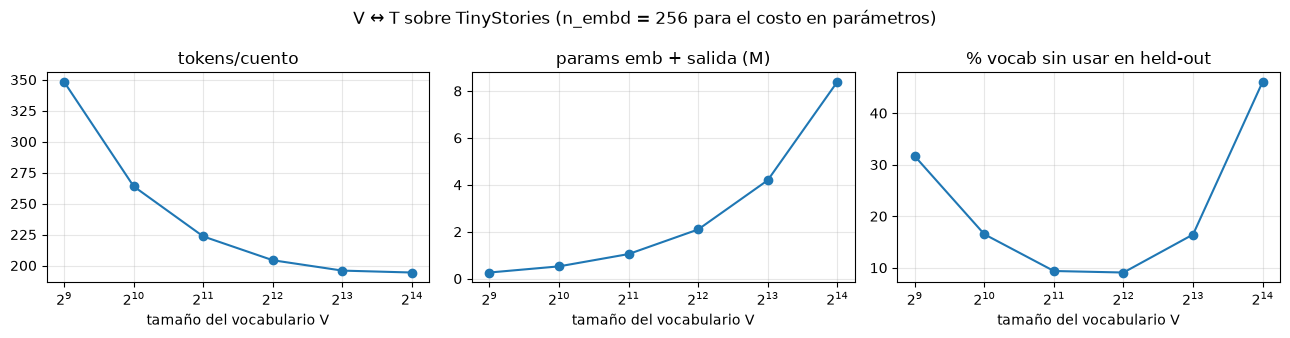

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, column in zip(axes, sweep.columns):
    ax.plot(sweep.index, sweep[column], marker="o")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("tamaño del vocabulario V")
    ax.set_title(column)
    ax.grid(alpha=0.3)
fig.suptitle(f"V ↔ T sobre TinyStories (n_embd = {N_EMBD_REFERENCE} para el costo en parámetros)")
fig.tight_layout()
fig.savefig(environment.CHECKPOINTS / "stage1_vocab_sweep.png", dpi=110)
plt.show()

### Lectura: las tres curvas, juntas

**Tokens por cuento (izquierda).** Cada vez que duplicamos `V`, ahorramos más o menos la mitad que la vez anterior:
−24%, −15%, −8,6%, −4,1% y, de 8.192 a 16.384, apenas −0,8%. La curva se aplana contra un piso. El *pre-tokenizador*
(el paso que corta el texto en palabras y signos antes del BPE) no deja que ningún merge junte una palabra con la coma
que le sigue, así que ningún vocabulario puede bajar de 193,6 tokens por cuento (anexo A). Con 16.384 ya estamos a un
0,4% de ese piso.

**Parámetros (centro).** Crecen en línea recta con `V`: duplicar el vocabulario duplica el costo. La curva parece una
exponencial solo porque el eje x está en escala logarítmica; es una trampa visual del gráfico.

**Vocabulario sin usar (derecha).** La forma de U engaña. Si pasamos los porcentajes a cantidad de filas, el número
**sube siempre**: 162, 169, 192, 372, 1.348 y 7.547. Detrás hay dos fenómenos distintos (anexo C):

- **A la izquierda**, casi todo son **bytes que no aparecen nunca** en estos cuentos: caracteres de control, bytes de
  letras de otros idiomas y símbolos de código como `( ) { } [ ] = _ #`, que no aparecen ni una vez en los 5.000
  cuentos. Son unas 160 filas fijas: con `V = 512` son un tercio del vocabulario, y con 8.192, un 2%.
- **A la derecha**, son **merges aprendidos que no aparecen en el held-out**. Algunos son pasos intermedios que un merge
  posterior se "comió", como `Ġbutterf`. Otros son palabras raras que el tokenizador vio en sus 20.000 cuentos de
  entrenamiento y que no vuelven a salir. Con 8.192 son 170 bytes + 401 intermedios + 776 raros + `<|endoftext|>`.

**Las tres juntas:** el codo está entre 2.048 y 8.192. Más abajo, los cuentos se alargan mucho. Más arriba, pagamos el
doble de parámetros y 5,6 veces más filas sin usar para ahorrar un 0,8% de tokens.

Dos matices que nos parecen importantes:

- **"Sin usar en 5.000 cuentos" no es lo mismo que "sin entrenar".** El modelo se entrena con muchos más cuentos, y ahí
  varias de estas filas aparecen, aunque sea pocas veces. Lo que sí es cierto es que el vocabulario tiene una cola
  larga: los 1.000 tokens más usados cubren el 90% del texto (anexo C), y las otras ~7.200 filas se reparten el 10%
  restante, así que se entrenan mucho menos.
- **Una fila que nunca entra igual recibe gradiente a la salida.** Si la capa de salida es una matriz aparte, como
  supone la cuenta de parámetros, en cada paso el softmax empuja hacia abajo la probabilidad de todos los tokens que no
  tocaban. Lo que se queda sin entrenar es su fila del *embedding de entrada*. Esa es la trampa que el notebook
  anticipa para la Etapa 3.

## Cuánto de un cuento entra en la ventana de contexto

Con el tokenizador elegido, el largo de cada cuento en tokens (+1 por el `<|endoftext|>` que lo separa del
siguiente). La Etapa 2 elige `block_size` entre 128 y 256: esto dice qué fracción de los cuentos el modelo
puede ver *enteros* dentro de una sola ventana.

tokens por cuento · mediana 182 · p90 255 · p99 544 · máx 1019
block_size 128:   6.1% de los cuentos entran enteros
block_size 192:  60.4% de los cuentos entran enteros
block_size 256:  90.2% de los cuentos entran enteros


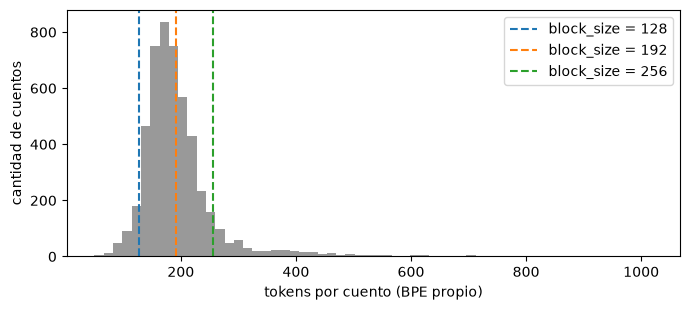

In [11]:
story_lengths = np.array([len(e.ids) + 1 for e in tokenizer.encode_batch(eval_texts)])

p50, p90, p99 = np.percentile(story_lengths, [50, 90, 99])
print(f"tokens por cuento · mediana {p50:.0f} · p90 {p90:.0f} · p99 {p99:.0f} · máx {story_lengths.max()}")
for block_size in (128, 192, 256):
    print(f"block_size {block_size}: {(story_lengths <= block_size).mean():6.1%} de los cuentos entran enteros")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(story_lengths, bins=60, color="0.6")
for block_size, color in zip((128, 192, 256), ("C0", "C1", "C2")):
    ax.axvline(block_size, color=color, ls="--", label=f"block_size = {block_size}")
ax.set_xlabel("tokens por cuento (BPE propio)")
ax.set_ylabel("cantidad de cuentos")
ax.legend()
fig.tight_layout()
fig.savefig(environment.CHECKPOINTS / "stage1_story_lengths.png", dpi=110)
plt.show()

### Lectura: cuánto de un cuento entra en la ventana

- **La forma:** una campana alrededor de 180 tokens (mediana 182), con una cola larga a la derecha (p99 = 544; el más
  largo tiene 1.019). 8 de cada 10 cuentos tienen entre 129 y 256 tokens.
- **Las tres líneas:** con 128 entra entero apenas el 6,1% de los cuentos (la línea cae en la ladera izquierda de la
  campana); con 192, el 60,4% (queda apenas por encima de la mediana); con 256, el 90,2% (coincide con el p90, que es
  255). Para llegar al 99% haría falta una ventana de ~544, más del doble, y el costo de la atención crece con el
  cuadrado del largo. **Por eso se eligió 256.**
- **Es el mismo codo que en el barrido de `V`:** cada paso compra menos. De 128 a 192 se suman 54 puntos; de 192 a
  256, 30; de 256 a 544, 9.
- **`V` y `block_size` son la misma decisión vista de dos lados.** Lo que importa es cuánto *cuento* entra en la
  ventana, y eso depende de los dos. Con `V = 512` un cuento promedio tiene 348 tokens: una ventana de 256 no alcanzaría
  ni para el promedio.

**Una duda sobre nuestra propia métrica.** "Entra entero" mide si un cuento *cabe*, no si el modelo lo *ve* entero. Si
el entrenamiento arma cada ventana cortando en una posición al azar el corpus concatenado (todos los cuentos pegados,
separados por `<|endoftext|>`), la ventana casi nunca empieza justo al principio de un cuento. Hicimos la cuenta: con
256, solo ~36% de las ventanas contiene algún cuento completo (~10% con 192), y el 18% de los tokens es de cuentos que
no entran en ninguna ventana (anexo D). O sea que el modelo aprende sobre todo con pedazos de cuentos, y tiene que usar
`<|endoftext|>` para darse cuenta de que dentro de la misma ventana empezó otra historia.

## Guardar

Se guarda y se vuelve a cargar, para confirmar que el archivo reproduce exactamente la misma codificación.

In [12]:
tokenizer.save(str(TOKENIZER_PATH))
reloaded = Tokenizer.from_file(str(TOKENIZER_PATH))
assert reloaded.encode(example).ids == encoding.ids
print(f"guardado: {TOKENIZER_PATH}  ({TOKENIZER_PATH.stat().st_size / 1e3:.0f} KB)")

guardado: /home/lucas/Proyecto1_IA_Generativa/checkpoints/tokenizer.json  (554 KB)


## Para el informe

- ¿Qué merges aparecieron primero, y qué dicen sobre cómo está armado este corpus? ¿Por qué *este* corpus
  produce *estos* merges y no, por ejemplo, un corpus de código?
- Con el vocabulario elegido, ¿cuántos tokens por cuento da en promedio, y cómo se compara con GPT-2 sobre
  los mismos cuentos? ¿Qué dice esa diferencia sobre el toma y daca `V ↔ T` en un corpus de vocabulario
  angosto?
- ¿Un vocabulario más chico es siempre mejor acá, o hay algo que se paga a cambio? (Mirar las tres curvas
  del barrido juntas.)

## Respuestas a las preguntas

### 1. ¿Qué merges aparecieron primero, qué dicen del corpus y por qué no se parecen a los de un corpus de código?

**Los primeros merges son los pedazos de un cuento narrado en pasado: comienzos de palabra, *the*, *and*, *to*, *he*,
*was* y el sufijo *-ed*. Salen esos porque el BPE es, literalmente, contar: une primero el par de símbolos que más se
repite en el corpus, y en estos cuentos lo que más se repite es eso.**

El BPE no "entiende" nada: cuenta qué par de símbolos aparece más veces pegado, lo une y repite. Por eso la lista de
merges funciona como una huella digital del corpus; mirándola se podría adivinar de qué tipo de texto salió. En
TinyStories lo que más se repite es la estructura de un cuento infantil: narración en pasado (*was*, *-ed*), en tercera
persona (*he*, *she*), con diálogo (*said*, comillas pegadas a la puntuación) y con un elenco chico de personajes que
vuelve una y otra vez: `ĠLily` se vuelve un token en el merge 108, antes que `Ġhappy` (146) o `Ġfriend` (158).

Para comprobar que es el corpus y no el algoritmo, comparamos con GPT-2, que usa el mismo BPE a nivel byte pero
entrenado sobre texto de internet. El número es el merge en el que nace cada token (anexo B):

| token | nuestro BPE | GPT-2 | qué representa |
|---|---:|---:|---|
| `Ġthe` | 7 | 7 | la palabra más común del inglés: igual en los dos |
| `ed` | 8 | 21 | pasado |
| `Ġhe` | 23 | 84 | tercera persona |
| `Ġwas` | 24 | 118 | narración en pasado |
| `Ġsaid` | 72 | 276 | diálogo |
| `Ġshe` | 79 | 418 | tercera persona |
| `Ġof` | 88 | 31 | prosa informativa (*one of the*, *the number of*) |
| `ic` | 214 | 36 | vocabulario técnico (*public*, *specific*) |
| `ion` | 503 | 40 | vocabulario abstracto (*information*, *nation*) |

Lo narrativo aparece mucho antes en el nuestro; lo informativo y formal (*of*, *-ion*, *-ic*), mucho antes en GPT-2.

**¿Y un corpus de código?** No lo probamos, así que es una predicción: los primeros merges serían los espacios de la
indentación, símbolos como `()`, `):` o ` =`, y palabras clave como `def`, `return` o `self`. En nuestros datos hay un
indicio de qué tan distinto sería: los símbolos típicos del código (`( ) { } [ ] = _ < > #`) no aparecen **ni una vez**
en los 5.000 cuentos held-out (anexo C). Para nuestro tokenizador son filas muertas; en un corpus de código estarían
entre los primeros merges.

### 2. Con el vocabulario elegido, ¿cuántos tokens por cuento da, cómo se compara con GPT-2 y qué dice eso del toma y daca `V ↔ T`?

**195,75 tokens por cuento en promedio (mediana 181), contra 199,05 de GPT-2: con un vocabulario 6 veces más chico,
partimos los mismos cuentos en un 1,7% menos de tokens. En un corpus de vocabulario angosto, pasados unos pocos miles
de tokens, agrandar `V` casi no acorta las secuencias y sí agranda mucho el modelo.**

El toma y daca `V ↔ T` dice que un vocabulario más grande (`V`) da secuencias más cortas (`T`), porque cada token cubre
más texto. Acá casi no se cumple, porque el corpus "se agota": TinyStories tiene pocas palabras distintas, y con 8.192
tokens casi todas ya son un token entero (solo el 0,9% de las palabras se parte; anexo A). Lo que queda sin comprimir
no son palabras sino puntuación, comillas y saltos de línea: el 17% de los tokens no tiene ni una letra. Esos signos el
pre-tokenizador los separa de las palabras *antes* del BPE, así que ningún vocabulario, por grande que sea, puede unir
*said* con la coma que le sigue. Por eso hay un piso: con este pre-tokenizador ningún vocabulario puede bajar de
**193,6 tokens por cuento**, y nosotros estamos a un 1,1% de él.

Eso explica a los dos tokenizadores grandes:

- **GPT-2 pierde** porque sus 50.257 entradas se gastaron en internet: código, nombres propios, otros idiomas. Para
  nuestros cuentos le sobran casi todas, y le faltan algunas que nosotros sí tenemos (`Kitty` en un solo token).
- **cl100k gana, pero no por su vocabulario enorme**, sino sobre todo por otras reglas de corte: pega los saltos de
  línea a la puntuación (un `."` seguido de dos saltos de línea es un solo token). Nosotros gastamos 7,2 tokens por
  cuento solo en saltos de línea y cl100k 3,7 (anexo A). Solo esa diferencia son 3,5 tokens por cuento, de una ventaja
  total de 4,8 (195,75 − 190,92).

Nuestra conclusión: en un corpus angosto, el largo de las secuencias depende más de *cómo se corta* el texto que del
tamaño del vocabulario. El costo del vocabulario, en cambio, crece sin techo: 4,19M de parámetros para nosotros,
25,73M con GPT-2 y 51,34M con cl100k.

### 3. ¿Un vocabulario más chico es siempre mejor acá, o hay algo que se paga a cambio?

**No es siempre mejor. Un vocabulario chico ahorra parámetros, pero alarga los cuentos, y eso se paga en ventana, en
datos vistos y en trabajo para el modelo. Uno grande tampoco sirve: pasado el codo, se paga el doble para no ganar
nada. Para nosotros la zona buena va de 2.048 a 8.192, y no estamos seguros de que 8.192 le gane a 4.096.**

Lo que se paga con `V = 512`, mirando las tres curvas juntas:

- **Secuencias un 78% más largas** (348 tokens por cuento contra 196). Con una ventana de 256 no entraría ni un cuento
  promedio.
- **Menos cuentos por el mismo cómputo.** Con un presupuesto fijo de tokens de entrenamiento, el modelo vería un 44%
  menos de cuentos, porque cada uno gasta 349 tokens en lugar de 197 (contando el `<|endoftext|>`).
- **Más trabajo para el modelo.** Si las palabras llegan partidas, es de esperar que parte de su capacidad se vaya en
  rearmarlas antes de poder ocuparse del cuento.
- **Y ni siquiera es eficiente en filas:** un tercio de su vocabulario son bytes que no aparecen nunca.

Del otro lado, pasar de 8.192 a 16.384 duplica el costo (de 4,19M a 8,39M) para ahorrar un 0,8% de tokens, y casi la
mitad del vocabulario queda sin aparecer en el held-out.

**La duda que nos queda es entre 4.096 y 8.192.** Con 4.096 los cuentos serían un 4,3% más largos (204 tokens contra
196), pero la tabla de embeddings y la de salida costarían la mitad (2,10M contra 4,19M) y habría 3,6 veces menos
filas sin usar en el held-out (372 contra 1.348). A favor de 8.192: es el techo del rango que sugiere la consigna, está
cerca de los ~10K que usó el paper de TinyStories, y deja más palabras enteras para analizar en la Etapa 3. El
experimento que zanjaría la discusión es preentrenar el mismo modelo con los dos vocabularios y comparar. No lo
hicimos, porque implicaba repetir toda la Etapa 2.

**Una trampa para quien haga esa comparación:** la pérdida por token no se puede comparar entre vocabularios
distintos. Con `V = 512` la pérdida arrancaría en ln 512 ≈ 6,2 y no en ln 8.192 ≈ 9,0, sin que el modelo sea mejor:
cada token "dice" menos. Hay que pasarla a una unidad que no dependa del tokenizador, como bits por carácter:
`L / (4,15 · ln 2)` para el nuestro, donde `L` es la pérdida por token en nats y 4,15 son los caracteres por token de
la tabla.

## Decisiones, diseño y reflexión

Qué elegimos en esta etapa, por qué, y qué nos costó:

1. **BPE a nivel byte, con `tokenizers` de HuggingFace** (la librería de bajo nivel). Lo pide la consigna y es lo que
   usa GPT-2. Partir de los 256 bytes garantiza que cualquier texto se pueda codificar sin un token `<unk>` (la ida y
   vuelta dio 5.000 de 5.000). *Costo:* unas 160 de esas 256 filas no se usan nunca en estos cuentos.
2. **`V = 8.192`**, el techo del rango que sugiere la consigna (4.096–8.192) y cerca de los ~10K del paper. Con este
   tamaño casi toda palabra es un token, las secuencias quedan cortas y más arriba ya no se gana nada. *Duda:* 4.096
   podía ser igual de bueno para un modelo chico (ver la respuesta 3).
3. **Entrenar con los primeros 100.000 cuentos del split `train`**, el 4,7% de los 2.119.719. Tarda unos 10 segundos y
   alcanza: el tokenizador del barrido, entrenado con 5 veces menos cuentos (20.000), da casi lo mismo con
   `V = 8.192` (195,90 contra 195,75 tokens por cuento). *Duda:* son los primeros 100.000, no una muestra al azar; si el
   dataset tiene algún orden interno, podría haber un sesgo. No lo chequeamos.
4. **Medir sobre 5.000 cuentos del split `validation`**, que el tokenizador nunca vio. Medir sobre sus propios cuentos
   de entrenamiento sería hacernos trampa: un BPE comprime mejor lo que ya vio.
5. **Un único token especial, `<|endoftext|>`**, para marcar dónde termina un cuento y empieza el siguiente cuando se
   concatenan. No hace falta `<unk>`, porque todo byte tiene su token.
6. **`add_prefix_space=False`**, como GPT-2. Los cuentos arrancan pegados al `<|endoftext|>` que los separa, sin
   espacio, así que es coherente que su primera palabra no lleve `Ġ`. *Costo:* la misma palabra ocupa filas distintas
   según dónde aparece. `Once` (inicio de cuento) nace en el merge 169, porque 3.327 de los 5.000 cuentos arrancan con
   "Once upon a time" (anexo E); `Ġonce` recién en el 2.650 y `ĠOnce` en el 5.344 (anexo B). Son tres filas para una
   misma palabra, y van a tener embeddings distintos.
7. **Comparar contra `gpt2` y `cl100k_base`**, contando el costo como `2 · V · n_embd` con `n_embd = 256`: dos matrices
   separadas, la de embeddings y la de salida. GPT-2 es el que pide la consigna; cl100k suma un tercer punto con un
   vocabulario gigante.
8. **Barrer `V` de 512 a 16.384 con tokenizadores entrenados sobre 20.000 cuentos**, para ver la curva entera y no un
   solo punto. Los 20.000 son para que los seis entrenamientos sean rápidos. *Consecuencia:* el punto 8.192 del barrido
   no coincide exacto con la tabla (195,90 contra 195,75 tokens por cuento, y 16,46% contra 15,55% de vocabulario sin
   usar; anexo C). Con 5 veces más datos, casi no cambia.
9. **Medir cuánto de un cuento entra en 128, 192 y 256 tokens**, como insumo para elegir `block_size`. Se eligió 256.
10. **`SEED` está definida pero no se usa, y no hace falta.** Entrenar un BPE no tiene azar: cuenta pares y une el más
    frecuente, y los cuentos son siempre los primeros N, no una muestra aleatoria. Lo comprobamos de tres formas:
    reentrenando por fuera salen exactamente los mismos números del barrido (anexo C); el `tokenizer.json` que
    generamos en otra computadora (Windows) es idéntico byte a byte, con el mismo SHA-1, al de esta corrida (Linux); y
    en otra corrida de este notebook lo único que cambió fue el tiempo (10,0 s contra 10,3 s) y el desempate de los
    tokens más largos.
11. **Corrió localmente** (Linux, con la RTX 5070 de una notebook) y no en Colab. Para esta etapa da igual: no usa GPU
    y tarda segundos.

### Registro de decisiones de la Etapa 1

- **Con qué contábamos:** esta etapa es obligatoria, alimenta a todas las demás con `checkpoints/tokenizer.json` y es
  barata (segundos de CPU). No había nada que recortar por tiempo ni por memoria.
- **Qué hicimos:** todo lo que pide la consigna, más tres cosas que no pedía: `cl100k` como tercer tokenizador, el
  barrido completo de `V` y la medición de la ventana de contexto.
- **Qué no hicimos, y por qué:** el experimento que de verdad contesta qué `V` conviene, que es preentrenar con 4.096 y
  con 8.192 y comparar en bits por carácter. Cada valor de `V` implica repetir la Etapa 2 entera.
- **Qué haríamos distinto sabiendo lo que sabemos ahora:** tomar una muestra al azar en vez de los primeros cuentos, y
  mirar el texto crudo antes de entrenar. El texto mal codificado de la sección siguiente lo encontramos recién al
  analizar los resultados.

## Dudas que nos quedan

- **El corpus trae texto mal codificado, y el tokenizador lo aprendió.** Cerca del 6% de los cuentos (302 de 5.000)
  tiene *mojibake*: en lugar del apóstrofo `’` aparece `â€™`, por ejemplo en `Benâ€™s`. El BPE no distingue un error
  de un patrón, así que le dedicó tokens: `donâ€™t` se parte en `ĠdonÃ¢` + `âĤ¬âĦ¢` + `t`, mientras que `don't` es
  `Ġdon` + `'t` (anexo E). Para el modelo son dos maneras distintas de escribir la misma palabra, y puede aprender a
  generar las dos. ¿Tendríamos que haber limpiado el texto antes? Probablemente sí, porque es barato. No lo hicimos
  porque lo vimos recién ahora, cuando el tokenizador ya lo usan las etapas siguientes: limpiarlo obligaría a
  reentrenar todo. Es una grieta en la idea de TinyStories como un instrumento de laboratorio "limpio".
- **¿Está bien que casi todo sea palabra entera?** `Ġplay`, `Ġplayed`, `Ġplaying` y `Ġplays` son cuatro filas
  independientes. Con un vocabulario más chico compartirían el pedazo `Ġplay`, y lo que el modelo aprendiera de una
  forma le serviría para las otras. Con el nuestro, el modelo tiene que descubrir solo, por el contexto, que están
  relacionadas. La Etapa 3 puede contestarlo mirando si terminan cerca.
- **Los primeros 100.000 cuentos no son una muestra al azar.** No sabemos si el orden del dataset tiene alguna
  estructura, por ejemplo por cómo se generaron los cuentos. Si la tiene, el tokenizador podría estar un poco sesgado.
- **Una conexión que nadie nos pidió: SolidGoldMagikarp.** El repositorio de arranque de la cátedra, del que sale este
  proyecto, es de `solidgoldmagickarp`, y no creemos que el nombre sea casualidad. ` SolidGoldMagikarp` es un token real del
  vocabulario de GPT-2, el 43.453 (anexo F). Es el nombre de un usuario de Reddit, y la explicación más aceptada es que
  aparecía mucho en los textos con los que se entrenó el tokenizador y casi nada en los datos del modelo. Su fila de
  embedding quedó prácticamente sin entrenar, y en 2023 se vio que los modelos que usaban ese vocabulario respondían
  cualquier cosa cuando se les pedía repetirlo. Es la versión extrema de las filas "sin usar" del barrido. En nuestro
  caso el riesgo es mucho menor, porque el tokenizador y el modelo se entrenan con el mismo corpus, pero no es cero: la
  cola larga del vocabulario existe igual.

Lo que sigue: Etapa 2 (`02_pretraining.ipynb`) — entrenar el Transformer sobre TinyStories con este tokenizador.

## Anexo: cómo medimos lo que no imprimen las celdas

Estos números no salen de las celdas de arriba: los medimos aparte, con el `tokenizer.json` guardado y los mismos
cuentos. Para no tocar el código del notebook los dejamos como texto. Se pueden pegar en una celda nueva al final,
porque usan variables que ya existen (`tokenizer`, `vocab`, `whole_words`, `train_texts`, `eval_texts`, `ours_total`,
`story_lengths`, `gpt2`, `cl100k`, `train_bpe` y `SWEEP_TRAIN_STORIES`). Debajo de cada uno está lo que imprime. Los
fragmentos C y G tardan un par de minutos; el resto, segundos.

**A · El piso de tokens y de qué están hechos**

```python
import re

pre = tokenizer.pre_tokenizer  # corta en palabras y signos ANTES del BPE: ningún merge cruza esos cortes
piso = np.mean([len(pre.pre_tokenize_str(s)) for s in eval_texts])
print(f"piso: {piso:.2f} tokens/cuento · BPE propio: {ours_total / len(eval_texts):.2f}")

palabras = [p for s in eval_texts[:2_000] for p, _ in pre.pre_tokenize_str(s) if re.search("[A-Za-z]", p)]
partidas = sum(len(tokenizer.model.tokenize(p)) > 1 for p in palabras)
print(f"palabras partidas en más de un token: {partidas / len(palabras):.1%}")

tokens = [t for e in tokenizer.encode_batch(eval_texts) for t in e.tokens]
print(f"tokens sin ninguna letra: {np.mean([not re.search('[A-Za-z]', t) for t in tokens]):.0%}")
saltos_cl100k = sum("\n" in cl100k.decode([i]) for ids in cl100k.encode_ordinary_batch(eval_texts) for i in ids)
print(f"tokens con salto de línea por cuento · BPE propio {sum('Ċ' in t for t in tokens) / len(eval_texts):.1f} "
      f"· cl100k {saltos_cl100k / len(eval_texts):.1f}")
```

Imprime:

```text
piso: 193.62 tokens/cuento · BPE propio: 195.75
palabras partidas en más de un token: 0.9%
tokens sin ninguna letra: 17%
tokens con salto de línea por cuento · BPE propio 7.2 · cl100k 3.7
```

**B · En qué merge nace cada token, acá y en GPT-2**

```python
# nuestro: id 0 = <|endoftext|> e ids 1–256 = bytes → merge = id − 256 · GPT-2: ids 0–255 = bytes → merge = id − 255
for t in ["Ġthe", "ed", "Ġhe", "Ġwas", "Ġsaid", "Ġshe", "Ġof", "ic", "ion"]:
    print(f"{t!r:>8}: merge {tokenizer.token_to_id(t) - 256:>4} nuestro · "
          f"{gpt2.encode_single_token(t.replace('Ġ', ' ')) - 255:>4} en GPT-2")
print({t: tokenizer.token_to_id(t) - 256 for t in ["ĠLily", "Ġhappy", "Ġfriend", '."', '!"', "Once", "Ġonce", "ĠOnce"]})
print(tokenizer.encode("Kitty smiled at Kitty").tokens, [gpt2.decode([i]) for i in gpt2.encode_ordinary("Kitty smiled at Kitty")])
```

Imprime:

```text
  'Ġthe': merge    7 nuestro ·    7 en GPT-2
    'ed': merge    8 nuestro ·   21 en GPT-2
   'Ġhe': merge   23 nuestro ·   84 en GPT-2
  'Ġwas': merge   24 nuestro ·  118 en GPT-2
 'Ġsaid': merge   72 nuestro ·  276 en GPT-2
  'Ġshe': merge   79 nuestro ·  418 en GPT-2
   'Ġof': merge   88 nuestro ·   31 en GPT-2
    'ic': merge  214 nuestro ·   36 en GPT-2
   'ion': merge  503 nuestro ·   40 en GPT-2
{'ĠLily': 108, 'Ġhappy': 146, 'Ġfriend': 158, '."': 165, '!"': 177, 'Once': 169, 'Ġonce': 2650, 'ĠOnce': 5344}
['Kitty', 'Ġsmiled', 'Ġat', 'ĠKitty'] ['K', 'itty', ' smiled', ' at', ' Kitty']
```

**C · De qué está hecha la "U" del barrido, y cuánto texto cubren los tokens más usados**

```python
def contar_uso(tok, textos, chunk=10_000):
    """Cuántas veces aparece cada id del vocabulario al tokenizar `textos` (de a `chunk` cuentos, por memoria)."""
    uso = np.zeros(tok.get_vocab_size(), dtype=np.int64)
    for i in range(0, len(textos), chunk):
        ids = np.concatenate([np.asarray(e.ids, dtype=np.int64) for e in tok.encode_batch(textos[i : i + chunk])])
        uso += np.bincount(ids, minlength=len(uso))
    return uso


# "intermedios": no aparecen ni en los cuentos con los que se entrenó ese tokenizador (un merge posterior se los comió)
# "raros": aparecen en esos cuentos, pero no en los 5.000 held-out
for vocab_size in (512, 4_096, 8_192, 16_384):
    cand = train_bpe(train_texts[:SWEEP_TRAIN_STORIES], vocab_size)
    uso_val, uso_train = contar_uso(cand, eval_texts), contar_uso(cand, train_texts[:SWEEP_TRAIN_STORIES])
    ids = np.arange(vocab_size)
    sin_usar = uso_val == 0
    print(f"V={vocab_size:>6,}: sin usar {sin_usar.sum():>5,} = <|endoftext|> {int(sin_usar[0])} "
          f"+ bytes {(sin_usar & (ids >= 1) & (ids <= 256)).sum()} "
          f"+ merges intermedios {(sin_usar & (ids > 256) & (uso_train == 0)).sum()} "
          f"+ merges raros {(sin_usar & (ids > 256) & (uso_train > 0)).sum()}")

print({c: sum(s.count(c) for s in eval_texts) for c in "(){}[]=_<>#"})  # símbolos de código en los 5.000 cuentos
uso_final = contar_uso(tokenizer, eval_texts)
print(f"tokenizador final, sin usar en el held-out: {(uso_final == 0).mean():.2%} · "
      f"los 1.000 tokens más usados cubren el {np.sort(uso_final)[::-1][:1_000].sum() / uso_final.sum():.1%} del texto")
```

Imprime:

```text
V=   512: sin usar   162 = <|endoftext|> 1 + bytes 161 + merges intermedios 0 + merges raros 0
V= 4,096: sin usar   372 = <|endoftext|> 1 + bytes 167 + merges intermedios 75 + merges raros 129
V= 8,192: sin usar 1,348 = <|endoftext|> 1 + bytes 170 + merges intermedios 401 + merges raros 776
V=16,384: sin usar 7,547 = <|endoftext|> 1 + bytes 183 + merges intermedios 2057 + merges raros 5306
{'(': 0, ')': 0, '{': 0, '}': 0, '[': 0, ']': 0, '=': 0, '_': 0, '<': 0, '>': 0, '#': 0}
tokenizador final, sin usar en el held-out: 15.55% · los 1.000 tokens más usados cubren el 90.2% del texto
```

**D · Cuántas ventanas al azar contienen un cuento entero**

```python
# Si el entrenamiento corta ventanas de B tokens en posiciones al azar del corpus concatenado, una ventana contiene
# entero un cuento de largo L solo si arranca en una de las B − L + 1 posiciones que lo dejan adentro.
for block_size in (128, 192, 256):
    ventanas = np.maximum(0, block_size + 1 - story_lengths).sum() / story_lengths.sum()
    no_entran = story_lengths[story_lengths > block_size].sum() / story_lengths.sum()
    print(f"block_size {block_size}: ~{ventanas:.0%} de las ventanas contiene un cuento entero · "
          f"{no_entran:.0%} de los tokens son de cuentos que no entran")
```

Imprime:

```text
block_size 128: ~1% de las ventanas contiene un cuento entero · 97% de los tokens son de cuentos que no entran
block_size 192: ~10% de las ventanas contiene un cuento entero · 51% de los tokens son de cuentos que no entran
block_size 256: ~36% de las ventanas contiene un cuento entero · 18% de los tokens son de cuentos que no entran
```

**E · Texto mal codificado, y cuántos cuentos arrancan igual**

```python
con_mojibake = sum("â€" in s for s in eval_texts)
print(f"cuentos con 'â€': {con_mojibake} ({con_mojibake / len(eval_texts):.1%})")
print(tokenizer.encode("I donâ€™t know").tokens, "vs", tokenizer.encode("I don't know").tokens)
print(f"arrancan con 'Once upon a time': {sum(s.startswith('Once upon a time') for s in eval_texts):,} de {len(eval_texts):,}")
```

Imprime:

```text
cuentos con 'â€': 302 (6.0%)
['I', 'ĠdonÃ¢', 'âĤ¬âĦ¢', 't', 'Ġknow'] vs ['I', 'Ġdon', "'t", 'Ġknow']
arrancan con 'Once upon a time': 3,327 de 5,000
```

**F · SolidGoldMagikarp**

```python
print(gpt2.encode_single_token(" SolidGoldMagikarp"))  # es un solo token del vocabulario de GPT-2
```

Imprime:

```text
43453
```

**G · Cuántos "tokens de palabra entera" son palabras de verdad**

```python
# Un token cuenta como palabra completa cuando él solo ocupa todo un pre-token (una palabra entre espacios o signos).
n_total = np.zeros(len(vocab), dtype=np.int64)
n_solo = np.zeros(len(vocab), dtype=np.int64)
for i in range(0, len(train_texts), 10_000):
    for e in tokenizer.encode_batch(train_texts[i : i + 10_000]):
        if not e.ids:
            continue  # hay algunos cuentos vacíos
        ids = np.asarray(e.ids)
        w = np.asarray([-1 if x is None else x for x in e.word_ids])  # a qué pre-token pertenece cada token
        solo = np.r_[True, w[1:] != w[:-1]] & np.r_[w[1:] != w[:-1], True]
        np.add.at(n_total, ids, 1)
        np.add.at(n_solo, ids[solo], 1)

candidatos = np.array([vocab[t] for t in whole_words])
vistos = n_total[candidatos] > 0
de_verdad = candidatos[vistos & (n_solo[candidatos] >= n_total[candidatos] / 2)]
comienzos = candidatos[vistos & (n_solo[candidatos] < n_total[candidatos] / 2)]
print(f"casi siempre palabra completa: {len(de_verdad):,} ({len(de_verdad) / len(vocab):.0%} del vocabulario) · "
      f"casi siempre comienzo de palabra: {len(comienzos):,} · nunca aparecen: {(~vistos).sum():,}")
print({t: (int(n_total[vocab[t]]), int(n_solo[vocab[t]])) for t in ["ĠBu", "Ġru", "Ġequ", "Ġday"]})
print("comienzos:", sorted((t for t in whole_words if n_total[vocab[t]] > 100 and n_solo[vocab[t]] == 0), key=vocab.get)[:10])
print("nunca vistos:", sorted((t for t in whole_words if n_total[vocab[t]] == 0), key=vocab.get)[:10])
```

Imprime:

```text
casi siempre palabra completa: 4,917 (60% del vocabulario) · casi siempre comienzo de palabra: 949 · nunca aparecen: 100
{'ĠBu': (86, 0), 'Ġru': (126, 0), 'Ġequ': (45, 0), 'Ġday': (126877, 126815)}
comienzos: ['Ġh', 'Ġwa', 'Ġg', 'Ġpl', 'Ġwh', 'Ġne', 'Ġsm', 'Ġbo', 'Ġse', 'Ġj']
nunca vistos: ['Ġbeaut', 'Ġsurpr', 'Ġadvent', 'Ġdiffere', 'Ġfav', 'Ġpare', 'Ġunderst', 'Ġbutterf', 'Ġgi', 'Ġdro']
```